# 09 · Rating curves

Fit a stage-discharge relationship to paired field measurements, then inspect residuals and segment choices.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Mississippi River at New Madrid, Missouri
The USGS 07024175 project stores 96 stage and 96 discharge observations in compressed fields.
Every timestamp pairs exactly, from February 2017 through March 2026. The original USGS responses are retained in the frozen source.
The app plots discharge horizontally and stage vertically; credible intervals are horizontal at a fixed stage.

,Series,Route,Type,Unit,Records,Start,End,Missing
0,USGS 07024175 Measured Stage,USGS,MeasuredStage,Gage Height (ft),96,2017-02-08T16:05:08.0000000Z,2026-03-19T16:02:34.0000000Z,0
1,USGS 07024175 Measured Discharge,USGS,MeasuredDischarge,Flow (cfs),96,2017-02-08T16:05:08.0000000Z,2026-03-19T16:02:34.0000000Z,0


,Setting,Saved choice
0,Analysis,RatingCurveAnalysis
1,StageData,USGS 07024175 Measured Stage
2,DischargeData,USGS 07024175 Measured Discharge
3,MinStage,-10.32
4,MaxStage,45.96
5,StageBins,100
6,UseDefaultStageBins,true
7,BayesianAnalysis.Type,DEMCzs
8,BayesianAnalysis.NumberOfChains,8
9,BayesianAnalysis.ThinningInterval,40


,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Zero-Flow Stage (h₁),-52.470744,False,-5.253000e+01,-0.94,Numerics.Distributions.Uniform
1,Coefficient (α₁),-0.412702,False,-1.000000e+01,10.00,Numerics.Distributions.Uniform
2,Exponent (β₁),3.328099,False,1.000000e-01,5.00,Numerics.Distributions.Uniform
3,Scale (σ),0.022508,False,1.110223e-16,1.00,Numerics.Distributions.Uniform


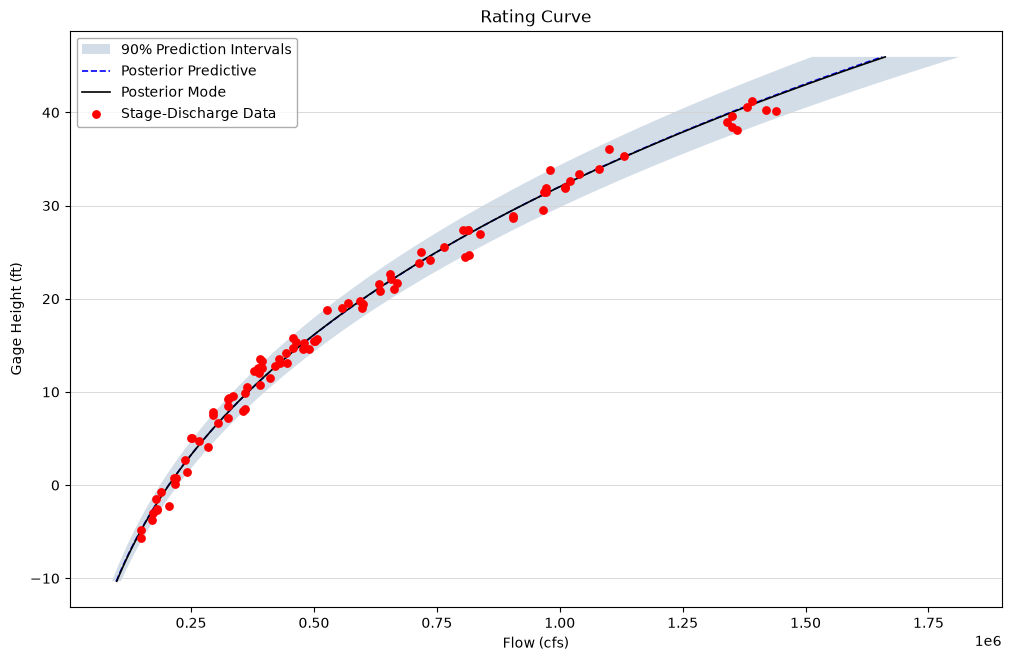

,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,USGS 07024175 Rating Curve,saved-app,sha256:997fe961e233,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


In [2]:
PROJECT = "usgs-07024175-mississippi-rating-curve"
project = load_project(PROJECT)
inventory = series_inventory(project)
display(inventory)
assert list(inventory["Records"]) == [96, 96]
rating = saved_case(PROJECT, "USGS 07024175 Rating Curve", run=RUN_ANALYSES)
display(rating.settings)
display(rating.parameters)
rating.show("curve")
display(case_provenance([rating]))

## Residual behavior
The residual scatter uses the fitted log10 discharge values and the app's residual definition.
The histogram's Normal overlay uses the saved error-scale parameter; its Q–Q reference uses the residual sample mean and standard deviation.
These views can reveal structure that an apparently smooth rating curve conceals.

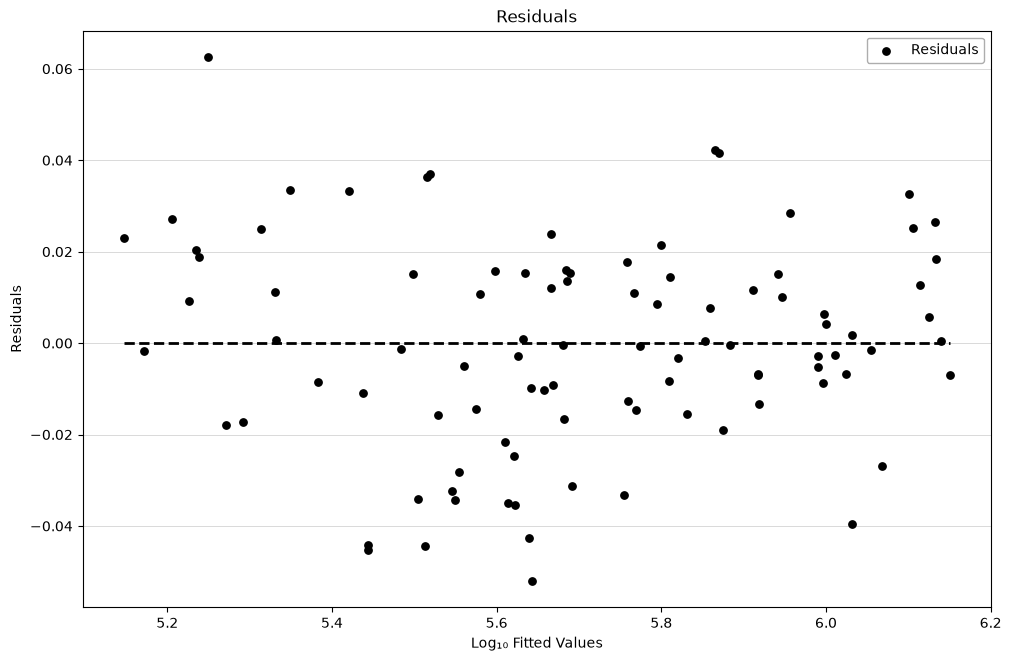

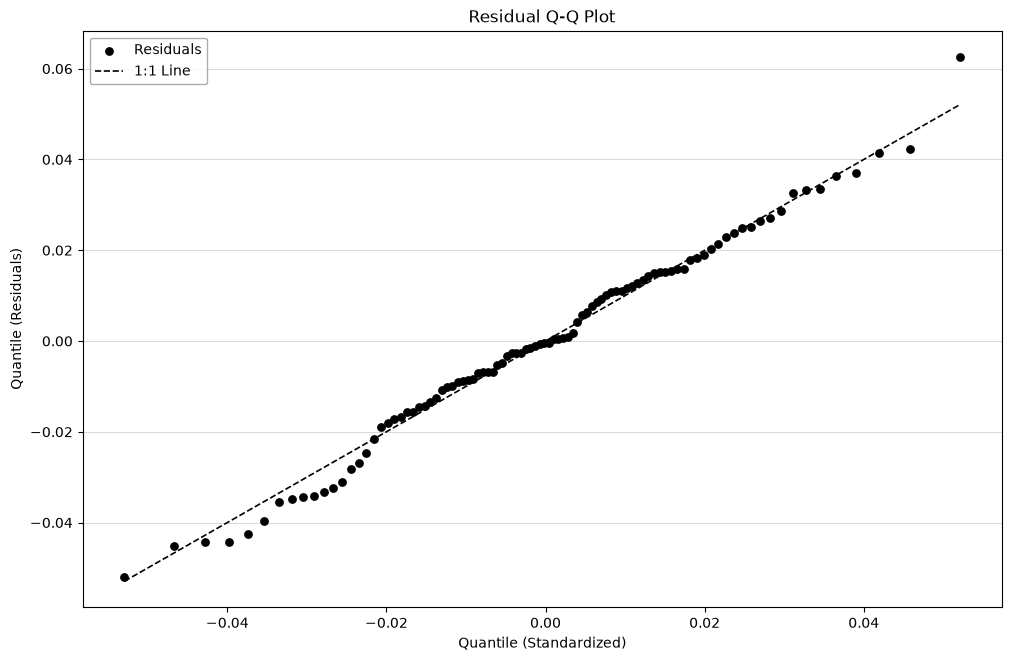

In [3]:
rating.show("residuals")
rating.show("residual_qq")

## One, two and three segments
The separate synthetic rating project contains 300 paired measurements for each segment configuration.
These controlled examples illustrate piecewise behavior. They are not evidence that a more complex model is required at New Madrid.
Their metrics describe separate simulated responses and are not ranked against one another or against the New Madrid fit.

In [4]:
synthetic = [saved_case("synthetic-rating-curve-examples", f"{n} Segment Rating Curve", run=RUN_ANALYSES) for n in (1,2,3)]
display(case_metrics(synthetic))
display(synthetic[1].parameters)
display(case_provenance(synthetic))

,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,1 Segment Rating Curve,see saved dependencies,RatingCurveAnalysis,3156.235968,3171.051098,3156.370501,224.364643,,Descriptive only — rows may use different resp...
1,2 Segment Rating Curve,see saved dependencies,RatingCurveAnalysis,3700.116115,3726.042592,3699.859997,2036.622768,,Descriptive only — rows may use different resp...
2,3 Segment Rating Curve,see saved dependencies,RatingCurveAnalysis,3779.386122,3816.423947,3774.226485,4042.050521,,Descriptive only — rows may use different resp...


,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Zero-Flow Stage (h₁),0.984439,False,-1.760902e+01,3.017615,Numerics.Distributions.Uniform
1,Coefficient (α₁),0.215392,False,-1.000000e+01,10.000000,Numerics.Distributions.Uniform
2,Exponent (β₁),2.700970,False,1.000000e-01,5.000000,Numerics.Distributions.Uniform
3,Activation Stage (h₂),9.847338,False,4.892764e+00,14.268507,Numerics.Distributions.Uniform
4,Coefficient (α₂),2.838395,False,-1.000000e+01,10.000000,Numerics.Distributions.Uniform
5,Exponent (β₂),1.787890,False,1.000000e-01,5.000000,Numerics.Distributions.Uniform
6,Scale (σ),0.050652,False,1.110223e-16,4.000000,Numerics.Distributions.Uniform


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,1 Segment Rating Curve,saved-app,sha256:e18dd2f001c4,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,2 Segment Rating Curve,saved-app,sha256:e18dd2f001c4,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
2,3 Segment Rating Curve,saved-app,sha256:e18dd2f001c4,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
